# How well do jobs and skills pay for Data Analysts?

## Methodology

1. Evaluate median salary for top 6 data jobs.
2. Find median salary per skill for Data Analysts.
3. Visualize for highest paying skills and most demanded skills.

In [1]:
# Importing Libraries
import ast
import seaborn as sns
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\basti\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_NL = df[(df["job_country"] == "Netherlands")].dropna(subset=["salary_year_avg"])

In [4]:
job_titles = df_NL["job_title_short"].value_counts().index[:6].tolist()

job_titles

['Data Engineer',
 'Data Analyst',
 'Data Scientist',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Business Analyst']

In [6]:
df_NL_top6 = df_NL[df_NL["job_title_short"].isin(job_titles)]

In [10]:
job_order = df_NL_top6.groupby("job_title_short")["salary_year_avg"].median().sort_values(ascending=False).index

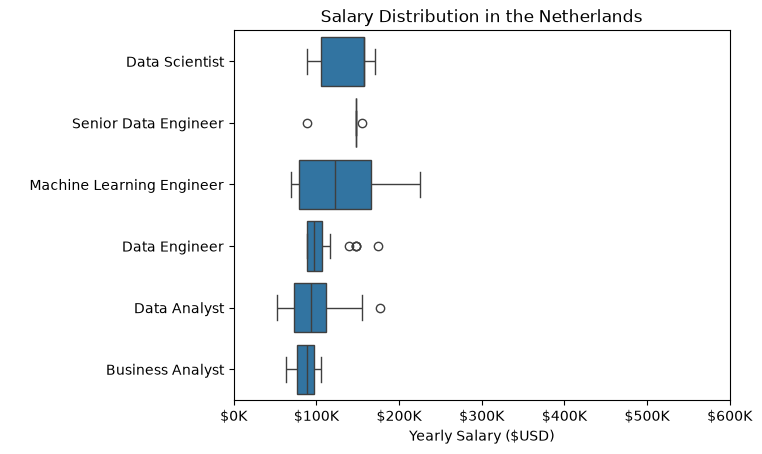

In [11]:
sns.boxplot(data=df_NL_top6, x="salary_year_avg", y="job_title_short", order=job_order)

plt.title("Salary Distribution in the Netherlands")
plt.xlabel("Yearly Salary ($USD)")
plt.ylabel(" ")
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K"))
plt.xlim(0, 600000)
plt.show()

# Investigate Median Salary Vs Skill for Data Analysts

In [13]:
df_DA_NL = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "Netherlands")].copy()

df_DA_NL = df_DA_NL.dropna(subset=["salary_year_avg"])

In [15]:
df_DA_NL = df_DA_NL.explode("job_skills")

df_DA_NL[["salary_year_avg", "job_skills"]].head(5)

,salary_year_avg,job_skills
13350,53014.0,sql
13350,53014.0,python
19026,155000.0,sap
134635,98500.0,sql
134635,98500.0,c#


In [19]:
df_DA_top_pay = df_DA_NL.groupby("job_skills")["salary_year_avg"].agg(["count", "median"]).sort_values(by="median", ascending=False)

df_DA_top_pay = df_DA_top_pay.head(10)

In [20]:
df_DA_skills = df_DA_NL.groupby("job_skills")["salary_year_avg"].agg(["count", "median"]).sort_values(by="count", ascending=False)

df_DA_skills = df_DA_skills.head(10).sort_values(by="median", ascending=False)

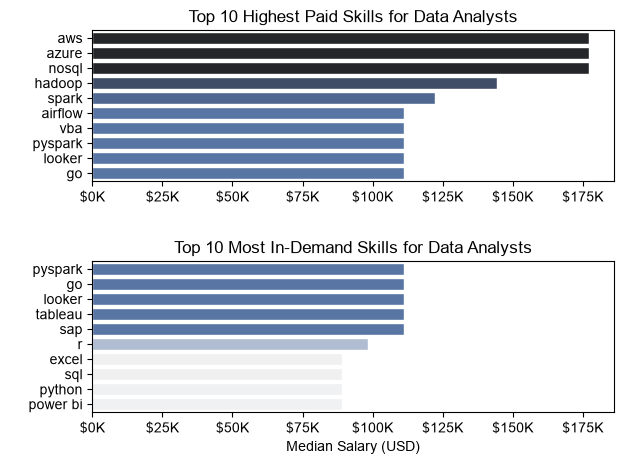

In [21]:
fig, ax = plt.subplots(2, 1)

sns.set_theme(style="ticks")

#df_DA_top_pay.plot(kind="barh", y="median", ax=ax[0], legend=False)
sns.barplot(data=df_DA_top_pay, x="median", y=df_DA_top_pay.index, ax=ax[0], hue="median", palette="dark:b_r")
#ax[0].invert_yaxis()
ax[0].legend().remove()
ax[0].set_title("Top 10 Highest Paid Skills for Data Analysts")
ax[0].set_ylabel(" ")
ax[0].set_xlabel(" ")
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K"))

#df_DA_skills.plot(kind="barh", y="median", ax=ax[1], legend=False)
sns.barplot(data=df_DA_skills, x="median", y=df_DA_skills.index, ax=ax[1], hue="median", palette="light:b")
#ax[1].invert_yaxis()
ax[1].legend().remove()
ax[1].set_title("Top 10 Most In-Demand Skills for Data Analysts")
ax[1].set_ylabel(" ")
ax[1].set_xlabel("Median Salary (USD)")
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K"))

plt.tight_layout()
plt.show()